In [1]:
import torch
import torch.nn as nn
import numpy as np
import scipy
import matplotlib.pyplot as plt
from datetime import date
from torch.utils.tensorboard import SummaryWriter
%load_ext tensorboard
%rm -rf ./log/
%mkdir log
%tensorboard --logdir=log/ --host localhost --port 6007

In [2]:
DATA_PATH = 'Data/cylinder_nektar_wake.mat'
DATA_PATH_VORTICITY = 'Data/cylinder_nektar_t0_vorticity.mat'

## Network Definition

We start by defining the network architecture: 3 dimensional input and output, 4 hidden layers with 60 neurons and tanh activation

We then initialize two models, a naive model and a physics-informed model 

In [3]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 60),
            nn.Tanh(),
            nn.Linear(60, 60),
            nn.Tanh(),
            nn.Linear(60, 60),
            nn.Tanh(),
            nn.Linear(60, 3),
        )
    
    def init_weights(self, m):
        if type(m) == nn.Linear:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3] # u, v,

model_pinn = PINN()
naive_model = PINN()


In [4]:
ns_wake_data = scipy.io.loadmat(DATA_PATH)

In [5]:
ns_vorticity = scipy.io.loadmat(DATA_PATH_VORTICITY)

In [6]:
ns_vorticity.keys()

dict_keys(['__header__', '__version__', '__globals__', 'modes', 'nel', 'w', 'x', 'y'])

In [7]:
ns_wake_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star'])

In [8]:
ns_wake_data['X_star'][0]

array([ 1., -2.])

In [9]:
ns_wake_data['U_star'].max()

np.float64(1.322556473239624)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import scipy.io
import numpy as np

def load_synthetic_data(file_path, N_train=10000):
    try:
        data = scipy.io.loadmat(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"No file {file_path} found.")

    # 2. Extract Raw Arrays
    # Assuming standard shapes: X_star (N, 2), t (T, 1), U_star (N, 2, T), P_star (N, T)
    t_star = data['t'].flatten()[:, None]  
    X_star = data['X_star']                
    U_star = data['U_star']                
    P_star = data['p_star']                

    N_spatial = X_star.shape[0]
    N_time = t_star.shape[0]

    # 3. Spatiotemporal Flattening (Meshgrid analog)
    # Tile the spatial coordinates for every time step
    x_flat = np.tile(X_star[:, 0:1], (1, N_time)).flatten()[:, None]
    y_flat = np.tile(X_star[:, 1:2], (1, N_time)).flatten()[:, None]
    
    # Repeat the time coordinates for every spatial point
    t_flat = np.repeat(t_star, N_spatial, axis=0)

    # Flatten the velocity and pressure fields correspondingly
    u_flat = U_star[:, 0, :].flatten()[:, None]
    v_flat = U_star[:, 1, :].flatten()[:, None]
    p_flat = P_star.flatten()[:, None]

    # 4. Stochastic Subsampling
    # We select N_train points randomly to serve as our empirical supervision anchors
    total_points = x_flat.shape[0]
    idx = np.random.choice(total_points, N_train, replace=False)

    # 5. Conversion to PyTorch Tensors
    to_tensor = lambda arr: torch.tensor(arr[idx, :], dtype=torch.float32)
    
    training_tensors = {
        'x': to_tensor(x_flat),
        'y': to_tensor(y_flat),
        't': to_tensor(t_flat),
        'u': to_tensor(u_flat),
        'v': to_tensor(v_flat),
        'p': to_tensor(p_flat)
    }
    
    print(f"Data parsed successfully. Subsampled {N_train} points from a total of {total_points}.")
    return training_tensors


training_data = load_synthetic_data(DATA_PATH)

Data parsed successfully. Subsampled 10000 points from a total of 1000000.


In [11]:
def compute_navier_stokes_residual(model, x, y, t, nu=0.01):
    """
    Evaluates the physical constraint violations (residuals) of the governing PDEs.
    """
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    
    u, v, p = model(x, y, t)
    
    # First-order derivatives
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    
    v_t = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]
    
    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, torch.ones_like(p), create_graph=True)[0]
    
    # Second-order derivatives (Kinematic viscosity diffusion)
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v_y), create_graph=True)[0]
    
    # Governing Equations
    f_u = u_t + u * u_x + v * u_y + p_x - nu * (u_xx + u_yy) # x-momentum
    f_v = v_t + u * v_x + v * v_y + p_y - nu * (v_xx + v_yy) # y-momentum
    f_c = u_x + v_y                                          # continuity
    
    return f_u, f_v, f_c

In [12]:
def train_hybrid_pinn(pinn, naive_model, data, rate, epochs, lambda_data = 1, lambda_pde = 1):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    print(f"Using device {device}")

    # send models and data to correct device
    pinn.to(device)
    naive_model.to(device)

    x, y, t = data['x'].to(device), data['y'].to(device), data['t'].to(device)
    u_true, v_true, p_true = data['u'].to(device), data['v'].to(device), data['p'].to(device)

    # initialize an optimizer for each model, one informed and one uninformed
    optimizer_1 = optim.Adam(pinn.parameters(), lr=rate)
    optimizer_2 = optim.Adam(naive_model.parameters(), lr=rate)
    epochs = epochs


    # set up loss history and tensorboard logger
    history = {"loss_naive": [], "loss_data_pinn": [], "loss_pde": [], "total_loss_pinn": []}
    tensorboard_hist = SummaryWriter(log_dir='log')
    
    for epoch in range(epochs):
        optimizer_1.zero_grad()
        optimizer_2.zero_grad()
        
        #forward pass for both models on the same data
        u_pred_pinn, v_pred_pinn, p_pred_pinn = pinn(x, y, t)
        u_pred_naive, v_pred_naive, p_pred_naive = naive_model(x, y, t)
        
        #compute data loss on informed model
        loss_data_pinn = torch.mean((u_pred_pinn - u_true)**2) + \
                    torch.mean((v_pred_pinn - v_true)**2) + \
                    torch.mean((p_pred_pinn - p_true)**2)
        
        #compute data loss on uninformed model
        loss_data_naive = torch.mean((u_pred_naive - u_true)**2) + \
                    torch.mean((v_pred_naive - v_true)**2) + \
                    torch.mean((p_pred_naive - p_true)**2)
                    
        #compute physical loss term (only for pinn)
        f_u, f_v, f_c = compute_navier_stokes_residual(pinn, x, y, t)
        
        loss_pde = torch.mean(f_u**2) + torch.mean(f_v**2) + torch.mean(f_c**2)
        
        #compute total loss for pinn
        loss_total = (lambda_data * loss_data_pinn) + (lambda_pde * loss_pde)
        
        #backpropagate total loss for pinn
        loss_total.backward()
        optimizer_1.step()

        #backpropagate only data loss for naive model
        loss_data_naive.backward()
        optimizer_2.step()

        history['loss_naive'].append(loss_data_naive.item())
        history['loss_data_pinn'].append(loss_data_pinn.item())
        history['loss_pde'].append(loss_pde.item())
        history['total_loss_pinn'].append(loss_total.item())

        tensorboard_hist.add_scalar("losses/Naive Model Data Loss", loss_data_naive.item(), epoch)
        tensorboard_hist.add_scalar("losses/Pinn Model Data Loss", loss_data_pinn.item(), epoch)
        tensorboard_hist.add_scalar("losses/PDE/Residual Loss", loss_pde.item(), epoch)
        tensorboard_hist.add_scalar("losses/PINN Total Loss", loss_total.item(), epoch)
        
        if epoch % 1000 == 0:
            print(f"Epoch {epoch:05d} | Total Loss: {loss_total.item():.4e} | "
                  f"Data Loss Naive: {loss_data_naive.item():.4e} | Data Loss PINN: {loss_data_pinn.item()} | PDE Loss: {loss_pde.item():.4e}")


    plt.figure()
    plt.plot(np.arange(len(history['loss_data_pinn'])), history['loss_data_pinn'], label = 'Supervised Loss PINN', color = 'blue')
    plt.plot(np.arange(len(history['loss_pde'])), history['loss_pde'], label = 'PDE Residual Loss', color = 'red')
    plt.plot(np.arange(len(history['loss_naive'])), history['loss_naive'], label = 'Supervised Loss NN', color = 'green')
    plt.plot(np.arange(len(history['total_loss_pinn'])), history['total_loss_pinn'], label = 'Total Informed Loss', color = 'yellow')
    plt.legend(loc = 'upper left')
    plt.title('Supervised Loss History')
    plt.ylabel('Loss Values Log Scale')
    plt.xlabel('Training Epochs')
    plt.yscale('log')
    
    plt.show()
    
    print("Saving model weigths...")
    torch.save(pinn.state_dict(), "Models/pinn_model_weigths_run_"+str(date.today()))
    torch.save(naive_model.state_dict(), "Models/naive_model_weights_run_"+str(date.today()))


    return pinn, naive_model

Using device mps
Epoch 00000 | Total Loss: 1.3527e+00 | Data Loss Naive: 1.1418e+00 | Data Loss PINN: 1.3496043682098389 | PDE Loss: 3.0528e-03
Epoch 01000 | Total Loss: 1.2510e-01 | Data Loss Naive: 1.2634e-01 | Data Loss PINN: 0.12235826998949051 | PDE Loss: 2.7451e-03
Epoch 02000 | Total Loss: 1.1040e-01 | Data Loss Naive: 1.0635e-01 | Data Loss PINN: 0.1085190623998642 | PDE Loss: 1.8833e-03
Epoch 03000 | Total Loss: 1.0554e-01 | Data Loss Naive: 1.0299e-01 | Data Loss PINN: 0.10417930036783218 | PDE Loss: 1.3622e-03
Epoch 04000 | Total Loss: 1.0241e-01 | Data Loss Naive: 1.0113e-01 | Data Loss PINN: 0.10150071978569031 | PDE Loss: 9.1119e-04
Epoch 05000 | Total Loss: 1.0063e-01 | Data Loss Naive: 1.0001e-01 | Data Loss PINN: 0.09999342262744904 | PDE Loss: 6.3960e-04
Epoch 06000 | Total Loss: 9.9620e-02 | Data Loss Naive: 9.8946e-02 | Data Loss PINN: 0.09916017949581146 | PDE Loss: 4.5972e-04
Epoch 07000 | Total Loss: 9.9267e-02 | Data Loss Naive: 9.8542e-02 | Data Loss PINN: 0.09

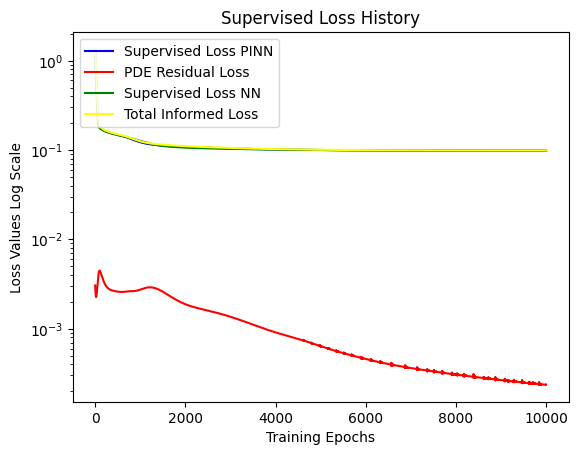

Saving model weigths...


In [13]:
trained_pinn, trained_naive = train_hybrid_pinn(pinn = model_pinn, naive_model = naive_model, data = training_data, rate = 1e-4, epochs = 10000)

In [19]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def visualize_navier_stokes_snapshot(model, exact_data, t_snapshot=10, device='mps', resolution=256):
    """
    Generates a high-fidelity comparative visualization of the velocity field (u-component)
    at a specific temporal cross-section.
    
    Parameters:
    - model: The trained PyTorch PINN or PI-KAN.
    - exact_data: Dictionary containing the SciPy-loaded ground truth grids.
    - t_snapshot: The specific time instance to visualize (e.g., t = 5.0).
    - device: 'cpu' or 'cuda'.
    - resolution: The density of the visualization mesh.
    """
    print(f"Extracting spatiotemporal cross-section at t = {t_snapshot}...")
    model.eval()
    
    # 1. Isolate the Ground Truth at t_snapshot
    # Assuming exact_data contains strictly meshed arrays: X_grid, Y_grid, T_grid, U_exact
    # We find the index in the time array closest to our target snapshot
    t_array = exact_data['t_unique'] # Assuming a 1D array of unique time steps
    t_idx = np.argmin(np.abs(t_array - t_snapshot))
    actual_t = t_array[t_idx]
    
    # Extract the 2D spatial grids and the exact velocity field at that specific time
    X_grid = exact_data['X_grid'][:, :, t_idx]
    Y_grid = exact_data['Y_grid'][:, :, t_idx]
    U_exact = exact_data['U_exact'][:, :, t_idx] # Shape: (N_y, N_x)
    
    # 2. Generate the Surrogate Model Prediction
    # Flatten the exact grids to pass them through the neural network
    x_flat = X_grid.flatten()[:, None]
    y_flat = Y_grid.flatten()[:, None]
    t_flat = np.full_like(x_flat, actual_t)
    
    # Convert to PyTorch tensors
    x_tensor = torch.tensor(x_flat, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_flat, dtype=torch.float32).to(device)
    t_tensor = torch.tensor(t_flat, dtype=torch.float32).to(device)
    
    # Forward pass (no gradients needed for visualization)
    with torch.no_grad():
        u_pred, v_pred, p_pred = model(x_tensor, y_tensor, t_tensor)
        
    # Transfer back to CPU and reshape to the 2D grid dimensions
    U_pred_grid = u_pred.cpu().numpy().reshape(X_grid.shape)
    
    # 3. Compute the Pointwise Absolute Error Manifold
    Error_grid = np.abs(U_exact - U_pred_grid)
    
    # 4. Construct the Matplotlib Figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f"Navier-Stokes $u$-Velocity Field Comparison at $t = {actual_t:.2f}$", fontsize=16)
    
    cmap_field = 'jet'
    cmap_error = 'magma'
    levels = 100
    
    # A. Plot Ground Truth
    ax0 = axes[0]
    c0 = ax0.contourf(X_grid, Y_grid, U_exact, levels=levels, cmap=cmap_field)
    ax0.set_title(r"Exact Solution $u_{true}(x, y)$", fontsize=14)
    ax0.set_xlabel("$x$")
    ax0.set_ylabel("$y$")
    ax0.set_aspect('equal')
    divider0 = make_axes_locatable(ax0)
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(c0, cax0=cax0)

    # B. Plot PINN Surrogate Prediction
    ax1 = axes[1]
    c1 = ax1.contourf(X_grid, Y_grid, U_pred_grid, levels=levels, cmap=cmap_field)
    ax1.set_title(r"Surrogate Prediction $u_\theta(x, y)$", fontsize=14)
    ax1.set_xlabel("$x$")
    ax1.set_aspect('equal')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(c1, cax1=cax1)

    # C. Plot Absolute Error
    ax2 = axes[2]
    c2 = ax2.contourf(X_grid, Y_grid, Error_grid, levels=levels, cmap=cmap_error)
    ax2.set_title(r"Absolute Error $|u_{true} - u_\theta|$", fontsize=14)
    ax2.set_xlabel("$x$")
    ax2.set_aspect('equal')
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(c2, cax2=cax2)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

    # Calculate and report the global L2 relative error norm for academic rigor
    l2_error = np.linalg.norm(U_exact - U_pred_grid) / np.linalg.norm(U_exact)
    print(f"Temporal Slice Global L2 Relative Error: {l2_error:.4e}")

In [20]:
visualize_navier_stokes_snapshot(trained_pinn, training_data)

Extracting spatiotemporal cross-section at t = 10...


KeyError: 't_unique'

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_pressure_comparison(model, data_dict, t_snapshot, nx, ny, device='mps'):
    """
    Produces two side-by-side heatmaps: Ground Truth vs. PINN Prediction.
    """
    model.eval()
    
    # 1. Recover the time index from the flattened data
    t_flat = data_dict['t']
    t_unique = np.unique(t_flat)
    t_idx = np.argmin(np.abs(t_unique - t_snapshot))
    actual_t = t_unique[t_idx]
    
    # 2. Extract Ground Truth Pressure Grid (P_star)
    # Mapping the flattened slice to (ny, nx)
    start_idx = t_idx * (nx * ny)
    end_idx = (t_idx + 1) * (nx * ny)
    
    p_ground_truth = data_dict['p'][start_idx:end_idx].reshape(ny, nx)
    x_grid = data_dict['x'][:nx*ny].reshape(ny, nx)
    y_grid = data_dict['y'][:nx*ny].reshape(ny, nx)
    
    # 3. Generate PINN Prediction
    x_tensor = torch.tensor(x_grid.flatten()[:, None], dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_grid.flatten()[:, None], dtype=torch.float32).to(device)
    t_tensor = torch.full_like(x_tensor, actual_t).to(device)
    
    # Handle Domain Normalization if you implemented it
    # x_tensor, y_tensor, t_tensor = normalize_inputs(x_tensor, y_tensor, t_tensor)

    with torch.no_grad():
        _, _, p_pred = model(x_tensor, y_tensor, t_tensor)
    
    p_pinn_grid = p_pred.cpu().numpy().reshape(ny, nx)
    
    # 4. Academic Normalization (Mean Centering)
    # This removes the arbitrary constant C(t) to allow shape comparison
    p_ground_truth -= np.mean(p_ground_truth)
    p_pinn_grid -= np.mean(p_pinn_grid)
    
    # 5. Determine Global Color Limits for Synchronized Scaling
    p_min = min(p_ground_truth.min(), p_pinn_grid.min())
    p_max = max(p_ground_truth.max(), p_pinn_grid.max())

    # 6. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    cmap = 'coolwarm'
    levels = 100
    
    # Subplot 1: Ground Truth
    im0 = axes[0].contourf(x_grid, y_grid, p_ground_truth, levels=levels, 
                           cmap=cmap, vmin=p_min, vmax=p_max)
    axes[0].set_title(f"Ground Truth Pressure $p(x, y)$\n(MATLAB Solver, $t={actual_t:.2f}$)", fontsize=14)
    axes[0].set_aspect('equal')
    
    # Subplot 2: PINN Prediction
    im1 = axes[1].contourf(x_grid, y_grid, p_pinn_grid, levels=levels, 
                           cmap=cmap, vmin=p_min, vmax=p_max)
    axes[1].set_title(f"PINN Predicted Pressure $\hat{p}(x, y)$\n(Surrogate Model, $t={actual_t:.2f}$)", fontsize=14)
    axes[1].set_aspect('equal')

    # Add shared colorbar
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(im1, cax=cbar_ax, label="Relative Kinematic Pressure")

    plt.show()

<>:63: SyntaxWarning: invalid escape sequence '\h'
<>:63: SyntaxWarning: invalid escape sequence '\h'
/var/folders/0p/3b6s1cyd2glf9kj66m2vt2gm0000gn/T/ipykernel_57961/1738179513.py:63: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title(f"PINN Predicted Pressure $\hat{p}(x, y)$\n(Surrogate Model, $t={actual_t:.2f}$)", fontsize=14)


In [47]:
domain_bounds = {'x': [training_data['x'].min(), training_data['y'].max()], 'y': [training_data['y'].min(), training_data['y'].max()]}

In [48]:
plot_pressure_comparison(trained_pinn, training_data, 10, 128, 128)

/var/folders/0p/3b6s1cyd2glf9kj66m2vt2gm0000gn/T/ipykernel_57961/1738179513.py:63: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title(f"PINN Predicted Pressure $\hat{p}(x, y)$\n(Surrogate Model, $t={actual_t:.2f}$)", fontsize=14)


RuntimeError: shape '[128, 128]' is invalid for input of size 0